This is a regression task that is designed to forecast the global active power  of a household.  
The dataset used to train the models is the [Individual Household Electric Power Consumption](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption) from UCI Machine Learning Repository

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
data = pd.read_csv('household_power_consumption.txt', sep=';', low_memory=False)

print(data.head())

         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  


# Data preprocessing + EDA

In [3]:
print(data.info(show_counts=True))

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   2075259 non-null  str    
 1   Time                   2075259 non-null  str    
 2   Global_active_power    2075259 non-null  str    
 3   Global_reactive_power  2075259 non-null  str    
 4   Voltage                2075259 non-null  str    
 5   Global_intensity       2075259 non-null  str    
 6   Sub_metering_1         2075259 non-null  str    
 7   Sub_metering_2         2075259 non-null  str    
 8   Sub_metering_3         2049280 non-null  float64
dtypes: float64(1), str(8)
memory usage: 142.5 MB
None


In [4]:
print((data['Global_active_power'] == '?').sum())

25979


In [3]:
cols = data.columns.tolist()
print(cols)

['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


In [4]:
for col in cols:
    empty_count = (data[col] == '?').sum()
    print('Missing values in ' + col + ' = ' + str(empty_count))

Missing values in Date = 0
Missing values in Time = 0
Missing values in Global_active_power = 25979
Missing values in Global_reactive_power = 25979
Missing values in Voltage = 25979
Missing values in Global_intensity = 25979
Missing values in Sub_metering_1 = 25979
Missing values in Sub_metering_2 = 25979
Missing values in Sub_metering_3 = 0


In [5]:
# converting "?" into np.nan
cols_containing_missing = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']

data[cols_containing_missing] = data[cols_containing_missing].replace('?', np.nan)
print(data.info(show_counts=True))

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   2075259 non-null  str    
 1   Time                   2075259 non-null  str    
 2   Global_active_power    2049280 non-null  str    
 3   Global_reactive_power  2049280 non-null  str    
 4   Voltage                2049280 non-null  str    
 5   Global_intensity       2049280 non-null  str    
 6   Sub_metering_1         2049280 non-null  str    
 7   Sub_metering_2         2049280 non-null  str    
 8   Sub_metering_3         2049280 non-null  float64
dtypes: float64(1), str(8)
memory usage: 142.5 MB
None


In [6]:
data.dropna(inplace=True)

print(data.info(show_counts=True))

<class 'pandas.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   2049280 non-null  str    
 1   Time                   2049280 non-null  str    
 2   Global_active_power    2049280 non-null  str    
 3   Global_reactive_power  2049280 non-null  str    
 4   Voltage                2049280 non-null  str    
 5   Global_intensity       2049280 non-null  str    
 6   Sub_metering_1         2049280 non-null  str    
 7   Sub_metering_2         2049280 non-null  str    
 8   Sub_metering_3         2049280 non-null  float64
dtypes: float64(1), str(8)
memory usage: 156.3 MB
None


In [7]:
for col in cols_containing_missing:
    data[col] = pd.to_numeric(data[col])

print(data.info(show_counts=True))

<class 'pandas.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   2049280 non-null  str    
 1   Time                   2049280 non-null  str    
 2   Global_active_power    2049280 non-null  float64
 3   Global_reactive_power  2049280 non-null  float64
 4   Voltage                2049280 non-null  float64
 5   Global_intensity       2049280 non-null  float64
 6   Sub_metering_1         2049280 non-null  float64
 7   Sub_metering_2         2049280 non-null  float64
 8   Sub_metering_3         2049280 non-null  float64
dtypes: float64(7), str(2)
memory usage: 156.3 MB
None


In [10]:
data.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


Separate the target variable from the independant variables

In [8]:
X = data.drop(columns=['Global_active_power'])
target = data['Global_active_power']

X.head()

,Date,Time,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,0.528,235.68,15.8,0.0,1.0,17.0


Processing date and time

In [9]:
X['Date_time'] = X['Date'] + ' ' + X['Time']
X.drop(columns=['Date', 'Time'], inplace=True)
X['Date_time'] = pd.to_datetime(X['Date_time'], dayfirst=True)

In [10]:
X['Date_time'].head(2)

0   2006-12-16 17:24:00
1   2006-12-16 17:25:00
Name: Date_time, dtype: datetime64[us]

In [11]:
X['month'] = X['Date_time'].dt.month
X['day'] = X['Date_time'].dt.day
X['year'] = X['Date_time'].dt.year
X['Day_of_week'] = X['Date_time'].dt.dayofweek
X['Week_of_year'] = X['Date_time'].dt.isocalendar().week

X.head(2)

,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Date_time,month,day,year,Day_of_week,Week_of_year
0,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,12,16,2006,5,50
1,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,12,16,2006,5,50


In [12]:
# extract necessary informations from the time feature

X['Hour'] = X['Date_time'].dt.hour
X['Minute'] = X['Date_time'].dt.minute

X.head(2)

,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Date_time,month,day,year,Day_of_week,Week_of_year,Hour,Minute
0,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,12,16,2006,5,50,17,24
1,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,12,16,2006,5,50,17,25


In [13]:
# drop the date-Time feature

X.drop(columns=['Date_time'], inplace=True)

X.head(1)

,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,month,day,year,Day_of_week,Week_of_year,Hour,Minute
0,0.418,234.84,18.4,0.0,1.0,17.0,12,16,2006,5,50,17,24


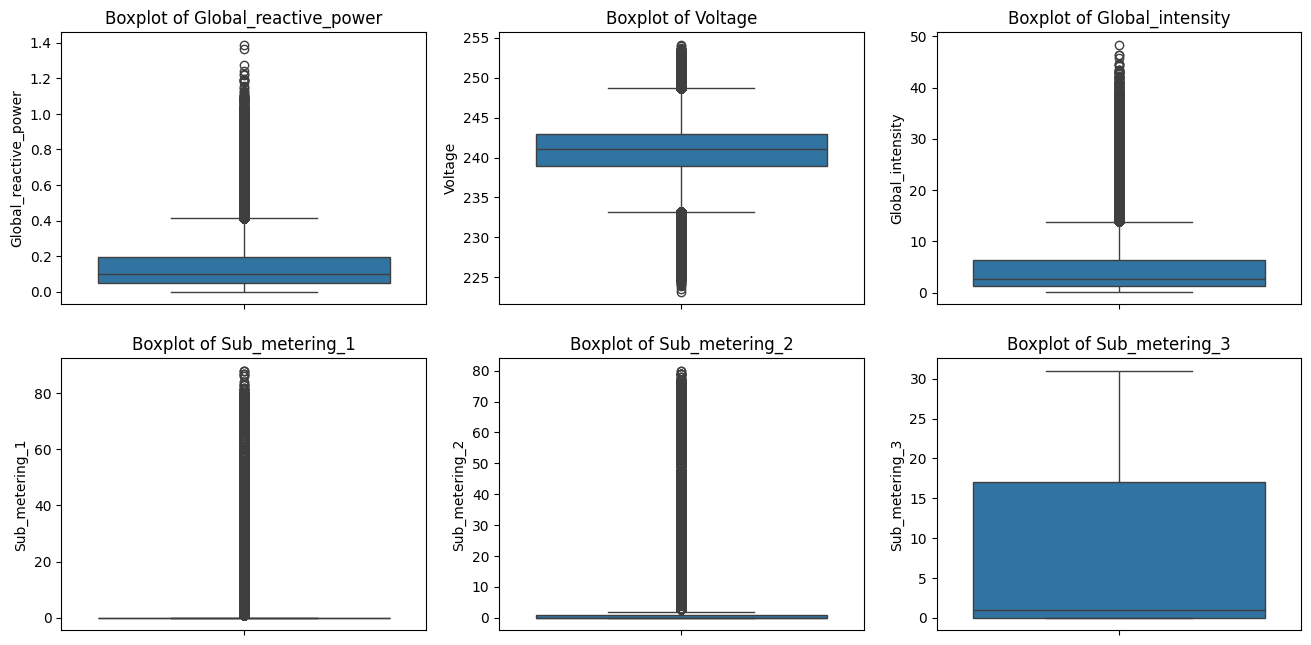

In [22]:
# drawing boxplot to visualize outliers
sensor_cols = ['Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

plt.figure(figsize=(16, 12))

for col in sensor_cols:
    plt.subplot(3, 3, sensor_cols.index(col)+1)
    sns.boxplot(data=X[col])
    plt.title('Boxplot of ' + col)

plt.show()

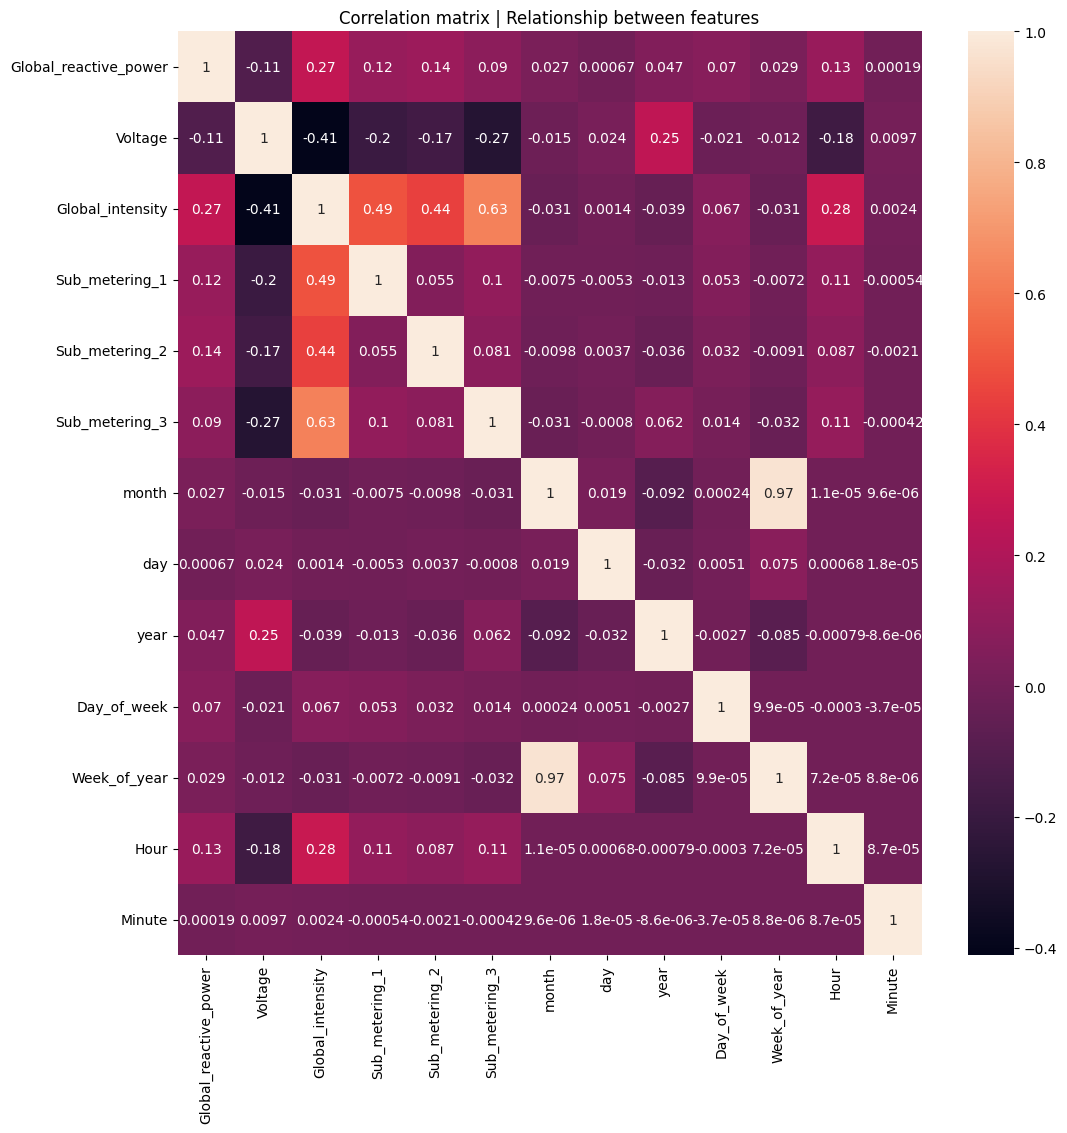

In [27]:
# compute the correlation matrix, then plot
X_corr = X.corr()

plt.figure(figsize=(12, 12))
sns.heatmap(X_corr, annot=True)
plt.title('Correlation matrix | Relationship between features')
plt.show()

In [28]:
# drop month column because this information is in week of year
X.drop(columns='month', inplace=True)
X.info(show_counts=True)

<class 'pandas.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 12 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Global_reactive_power  2049280 non-null  float64
 1   Voltage                2049280 non-null  float64
 2   Global_intensity       2049280 non-null  float64
 3   Sub_metering_1         2049280 non-null  float64
 4   Sub_metering_2         2049280 non-null  float64
 5   Sub_metering_3         2049280 non-null  float64
 6   day                    2049280 non-null  int32  
 7   year                   2049280 non-null  int32  
 8   Day_of_week            2049280 non-null  int32  
 9   Week_of_year           2049280 non-null  UInt32 
 10  Hour                   2049280 non-null  int32  
 11  Minute                 2049280 non-null  int32  
dtypes: UInt32(1), float64(6), int32(5)
memory usage: 158.3 MB


Data split

In [29]:
X_train, X_test, target_train, target_test = train_test_split(X, target, test_size=0.3, random_state=42)

Scale each features by using Standardization because, on the one hand, algorithms which assume normally distributed data like Linear regression and SVM are going to be used, on the other hand, some features contain outliers

In [30]:
scaler = StandardScaler()

In [31]:
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Model training

In [35]:
lr_model = LinearRegression()
svr_default = SVR()

In [36]:
lr_model.fit(X_train, target_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
svr_default.fit(X_train, target_train)